# PREGUNTAS DE NEGOCIO

# 1. Prevalencia de Anemia por Orden de Nacimiento

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual global
sns.set_theme(style="whitegrid")

# 1. Definición dinámica de la ruta desde 'notebooks/' hacia 'data/processed/'
RUTA_ACTUAL = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(RUTA_ACTUAL, "..")) if os.path.basename(RUTA_ACTUAL) == "notebooks" else RUTA_ACTUAL
DIR_PROCESSED = os.path.join(BASE_DIR, "data", "processed")

path_parquet = os.path.join(DIR_PROCESSED, "endes_2025_nutricion_m1638_enriquecido.parquet")

# 2. Carga del dataset transformado
if os.path.exists(path_parquet):
    df_merged = pd.read_parquet(path_parquet)
    print(f" Dataset cargado con éxito desde: {path_parquet}")
    print(f" Registros: {len(df_merged):,} | Columnas: {len(df_merged.columns)}")
else:
    raise FileNotFoundError(f" No se encontró el archivo en: {path_parquet}")

 Dataset cargado con éxito desde: c:\ESTUDIOS\CIBERTEC\Ciclo4_LenguajeCienciaDatos2\T1_grupal_V3\PROYECTO-AVANCE\PROYECTO-AVANCE\data\processed\endes_2025_nutricion_m1638_enriquecido.parquet
 Registros: 18,841 | Columnas: 77


TABLA: Prevalencia de Anemia por Orden de Nacimiento (Variables Derivadas)


,tipo_orden_nacimiento,total_niños,casos_anemia,porcentaje_anemia
0,1. Primogénito,16933,5355,31.62%
1,2. Segundo/Tercer Hijo,1908,402,21.07%


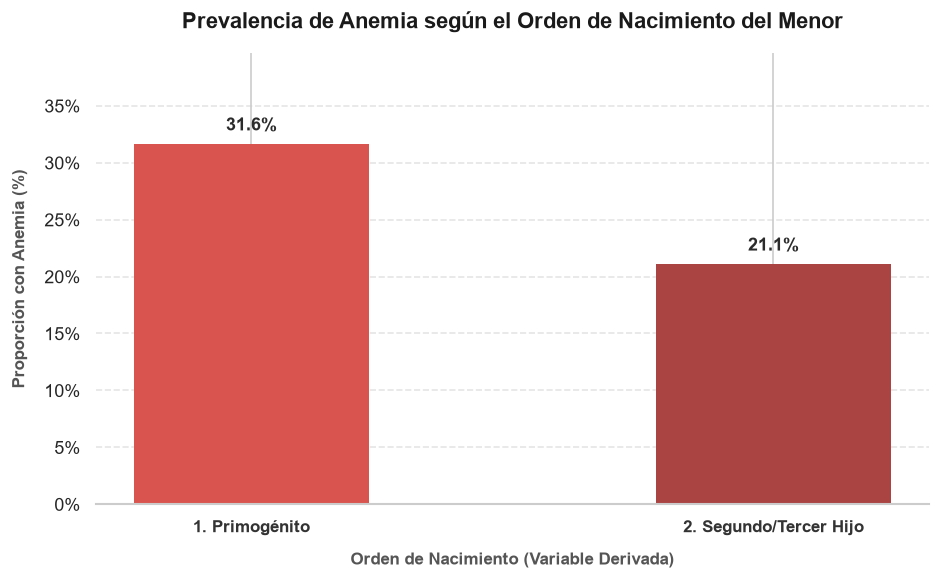

In [42]:
# --- TABLA RESUMEN DE LA TÉCNICA 1 ---
print("TABLA: Prevalencia de Anemia por Orden de Nacimiento (Variables Derivadas)")

tabla_t1 = df_merged.groupby('tipo_orden_nacimiento').agg(
    total_niños=('caseid', 'count'),
    casos_anemia=('tiene_anemia', 'sum'),
    porcentaje_anemia=('tiene_anemia', lambda x: f"{x.mean()*100:.2f}%")
).reset_index()

display(tabla_t1)

# --- GRÁFICO SEABORN ---
# Configuración de estilo limpio
sns.set_theme(style="whitegrid", font="sans-serif")

# Preparación de datos agregados para graficar
df_plot = df_merged.groupby('tipo_orden_nacimiento', as_index=False)['tiene_anemia'].mean()
df_plot['porcentaje'] = df_plot['tiene_anemia'] * 100

# Definir figura
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# Paleta de colores profesional (Gradiente sobrio)
colores = ['#D9534F', '#A94442', '#702120']

# Dibujar barras centradas
bars = ax.bar(
    x=df_plot['tipo_orden_nacimiento'], 
    height=df_plot['porcentaje'], 
    color=colores[:len(df_plot)],
    width=0.45,  # Ancho de barra óptimo
    edgecolor="none"
)

# Centrado exacto de los ticks y etiquetas en el eje X
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['tipo_orden_nacimiento'], fontsize=10, fontweight='bold', color='#333333')

# Título y Subtítulo estilizados
ax.set_title('Prevalencia de Anemia según el Orden de Nacimiento del Menor', 
             fontsize=13, fontweight='bold', color='#1A1A1A', pad=15)
ax.set_xlabel('Orden de Nacimiento (Variable Derivada)', fontsize=10, fontweight='bold', color='#555555', labelpad=10)
ax.set_ylabel('Proporción con Anemia (%)', fontsize=10, fontweight='bold', color='#555555', labelpad=10)

# Formato del eje Y (porcentajes) y límite para dar aire a los data labels
ax.set_ylim(0, max(df_plot['porcentaje']) + 8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

# Ocultar bordes innecesarios (Top, Right, Left) para un acabado minimalista
sns.despine(top=True, right=True, left=True)

# Añadir etiquetas de datos (Data Labels) con diseño limpio
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),  # Elevación respecto a la barra
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#2B2B2B'
        )

# Ajuste de rejilla secundaria tenue en el eje Y
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analisis del caso:

### Hallazgos Principales
Mayor prevalencia en primogénitos:
* Los niños primogénitos presentan una tasa de anemia del 31.62%, equivalente a 5,355 casos de un total de 16,933 menores evaluados.
  Este grupo concentra el 89% del total de la muestra, lo que refuerza su relevancia epidemiológica.

* Menor prevalencia en segundos/terceros hijos:
  Los niños segundo o tercer hijo registran una prevalencia de 21.07%, con 402 casos sobre 1,908 evaluados.
  La diferencia entre ambos grupos es de 10.55 puntos porcentuales, lo que evidencia una brecha significativa en el riesgo de anemia.

#### Conclusión:
El riesgo de anemia es considerablemente mayor en los primogénitos, lo que sugiere que la falta de experiencia materna y el menor conocimiento sobre prácticas de nutrición infantil podrían influir en esta diferencia.

#### Recomendaciones Estratégicas
* Acompañamiento a madres primerizas
   Implementar talleres de nutrición y suplementación con hierro desde el primer trimestre de embarazo.
   Reforzar el control CRED con visitas domiciliarias y consejería nutricional durante el primer año de vida.

* Digitalización y alertas tempranas
  Configurar alertas automáticas en el PADRÓN NOMINAL para priorizar tamizajes de hemoglobina en primogénitos.
  Enviar recordatorios automatizados (SMS/WhatsApp) sobre fechas de tamizaje y recojo de suplementos.

* Articulación intersectorial MINSA–MIDIS
  Integrar programas sociales como Cuna Más y Juntos para focalizar hogares jóvenes con su primer hijo.
  Desarrollar campañas de sensibilización sobre la importancia del hierro en lactantes.

* Monitoreo y evaluación continua
  Implementar tableros de control automatizados para seguimiento mensual de cobertura y recuperación de anemia por departamento y distrito.

##  2. Impacto Geográfico y Focalización de Anemia

### A continuación se presenta 2 formas de visualizar la data.

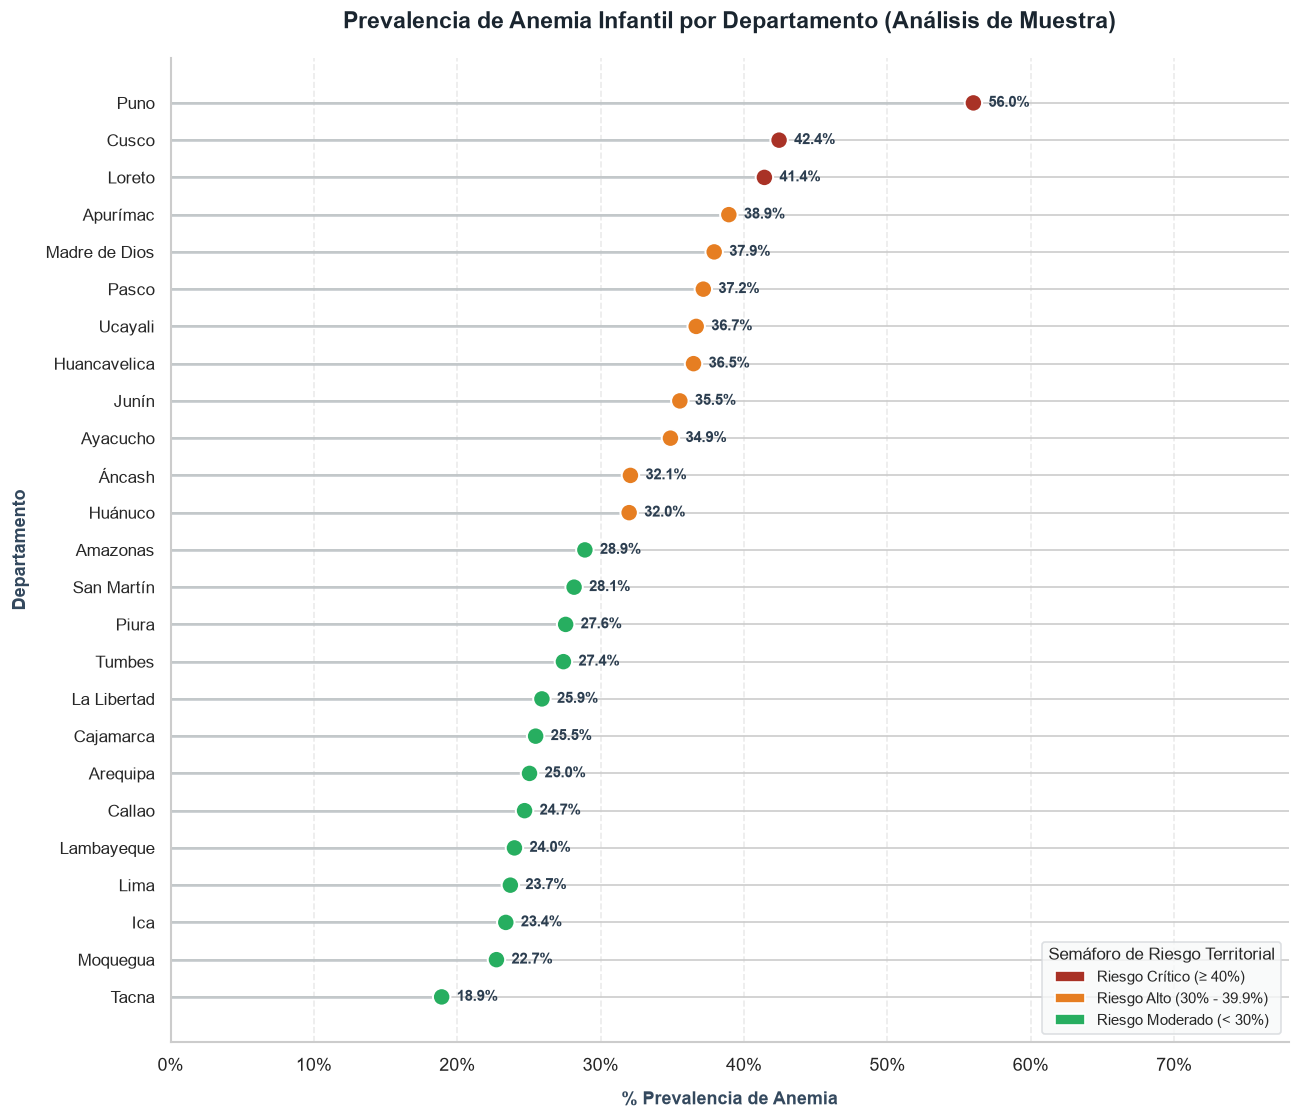

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Estilo visual limpio y corporativo
sns.set_theme(style="whitegrid", font="sans-serif")

# =============================================================================
# 1. PREPARACIÓN DE DATOS Y MÉTRICAS DE MUESTRA
# =============================================================================
df_lol = df_merged.groupby('nombre_departamento').agg(
    total_evaluados=('caseid', 'count'),
    total_casos=('tiene_anemia', 'sum'),
    pct_anemia=('tiene_anemia', lambda x: x.mean() * 100)
).sort_values(by='pct_anemia', ascending=True).reset_index()  # Ascendente para Lollipop

# Asignar colores condicionales según el nivel de riesgo
colores = ['#A93226' if x >= 40 else ('#E67E22' if x >= 30 else '#27AE60') for x in df_lol['pct_anemia']]

# =============================================================================
# 2. GENERACIÓN DEL GRÁFICO EJECUTIVO (LOLLIPOP CHART)
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 9.5), dpi=120)

# Dibujar las líneas de la paleta (hlines)
ax.hlines(
    y=df_lol['nombre_departamento'], 
    xmin=0, 
    xmax=df_lol['pct_anemia'], 
    color='#BDC3C7', 
    alpha=0.7, 
    linewidth=1.8,
    zorder=2
)

# Dibujar los marcadores circulares principales
ax.scatter(
    df_lol['pct_anemia'], 
    df_lol['nombre_departamento'], 
    color=colores, 
    s=110, 
    edgecolor='white',
    linewidth=1.2,
    zorder=3
)

# Títulos y Etiquetas de Eje
ax.set_title("Prevalencia de Anemia Infantil por Departamento (Análisis de Muestra)", 
             fontsize=13.5, fontweight='bold', color='#1A252F', pad=18)
ax.set_xlabel("% Prevalencia de Anemia", fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)
ax.set_ylabel("Departamento", fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)

# Formatear Eje X a Porcentaje y ampliar margen para el texto
max_val = df_lol['pct_anemia'].max()
ax.set_xlim(0, max_val + 22)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.tick_params(axis='y', labelsize=10)

# =============================================================================
# 3. ETIQUETAS DETALLADAS Y LEYENDA INSTITUCIONAL
# =============================================================================
# Anotaciones numéricas con formato: % (casos / evaluados niños)
for i, row in df_lol.iterrows():
    pct = row['pct_anemia']
    casos = int(row['total_casos'])
    evaluados = int(row['total_evaluados'])
    
    ax.annotate(
        f"{pct:.1f}%  ",
        xy=(pct, row['nombre_departamento']),
        xytext=(9, 0),
        textcoords='offset points',
        ha='left', va='center',
        fontsize=9, fontweight='bold', color='#2C3E50'
    )

# Configuración de la Leyenda de Riesgo
legend_elements = [
    Patch(facecolor='#A93226', label='Riesgo Crítico (≥ 40%)'),
    Patch(facecolor='#E67E22', label='Riesgo Alto (30% - 39.9%)'),
    Patch(facecolor='#27AE60', label='Riesgo Moderado (< 30%)')
]

ax.legend(
    handles=legend_elements, 
    loc='lower right', 
    title="Semáforo de Riesgo Territorial", 
    title_fontsize='10', 
    fontsize='9', 
    frameon=True, 
    facecolor='#F8F9F9',
    edgecolor='#D5D8DC'
)

# Estilizado final de la gráfica
sns.despine(top=True, right=True)
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=1)

plt.tight_layout()
plt.show()

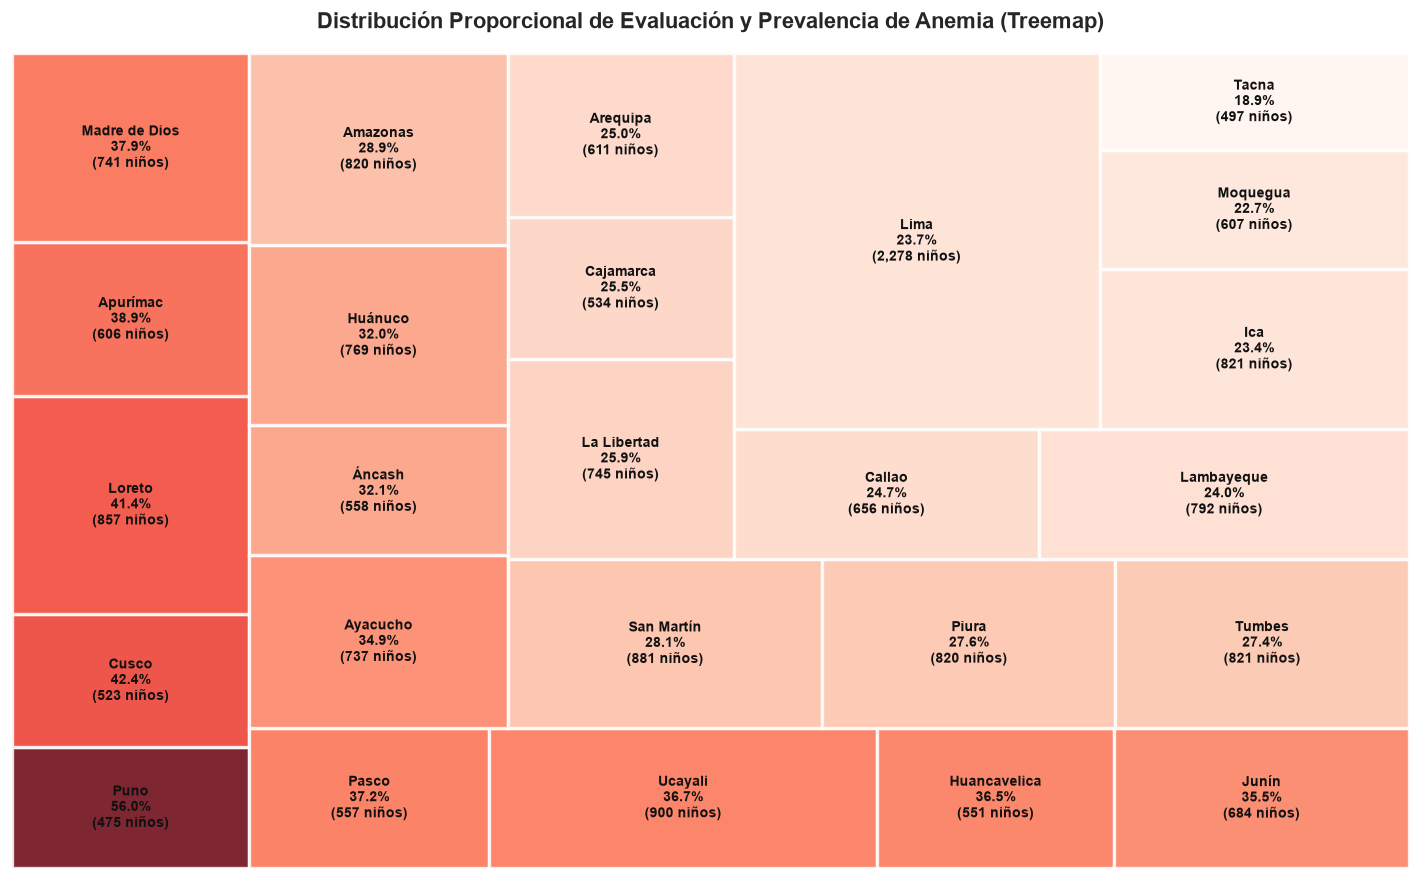

In [44]:
import sys
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Autoinstalación e importación segura de squarify
try:
    import squarify
except ImportError:
    print("Instalando la librería 'squarify' para el Treemap...")
    subprocess.run([sys.executable, "-m", "pip", "install", "squarify", "-q"])
    import squarify

# 2. Agregación de datos por Departamento
df_tree = df_merged.groupby('nombre_departamento').agg(
    evaluados=('caseid', 'count'),
    pct_anemia=('tiene_anemia', lambda x: x.mean() * 100)
).sort_values(by='pct_anemia', ascending=False).reset_index()

# 3. Configuración del mapa de colores (Rojo según la tasa de anemia)
norm = plt.Normalize(df_tree['pct_anemia'].min(), df_tree['pct_anemia'].max())
cmap = plt.cm.Reds
colors = [cmap(norm(value)) for value in df_tree['pct_anemia']]

# 4. Construcción de etiquetas dinámicas
labels = [f"{row['nombre_departamento']}\n{row['pct_anemia']:.1f}%\n({row['evaluados']:,} niños)" for _, row in df_tree.iterrows()]

# 5. Generación del Treemap
plt.figure(figsize=(12, 7.5), dpi=120)
squarify.plot(
    sizes=df_tree['evaluados'], 
    label=labels, 
    color=colors, 
    alpha=0.85, 
    text_kwargs={'fontsize': 8.5, 'fontweight': 'bold', 'color': '#111111'},
    bar_kwargs={'edgecolor': 'white', 'linewidth': 2}
)

plt.title("Distribución Proporcional de Evaluación y Prevalencia de Anemia (Treemap)", fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

## Analisis del caso:

#### Hallazgos Principales
* Condición de vulnerabilidad: Se identifican los departamentos con prevalencia de anemia infantil superior al 35%, considerados zonas de Extrema Vulnerabilidad Nutricional.
 - Puno (56%), Cusco (42.4%) y Loreto (41.4%) destacan como los departamentos con mayor prevalencia, evidenciando una situación de emergencia nutricional.
 - Estas regiones presentan además menor número de niños evaluados, lo que sugiere posibles brechas de cobertura en el tamizaje.

#### Conclusión
Existe una correlación territorial entre la prevalencia de anemia y las condiciones estructurales de pobreza, altitud y acceso limitado a servicios básicos.
La anemia infantil presenta un patrón territorial concentrado en zonas altoandinas y amazónicas, donde factores como la altitud, la pobreza estructural y las brechas de acceso a servicios básicos agravan la situación nutricional.
El mapa revela una desigualdad en la cobertura de evaluación, lo que implica que los departamentos con menor número de niños tamizados podrían estar subestimando su verdadera prevalencia.

#### Acciones Estratégicas Recomendadas
1. Reasignación presupuestal y logística territorial
   Declarar emergencia sanitaria en Puno y regiones con prevalencia >50%.
   Priorizar el abastecimiento de suplementos de hierro y micronutrientes en centros rurales.

2. Intervención adaptada al contexto regional
   Campañas interculturales en Quechua, Aymara y lenguas amazónicas para derribar mitos sobre suplementación.
   Despliegue de brigadas itinerantes (PIAS) en Loreto y Ucayali para tamizaje y entrega de alimentos fortificados.

3. Articulación interinstitucional agua y nutrición
   Coordinar con el Ministerio de Vivienda y gobiernos regionales la instalación de agua potable y saneamiento básico.
   Integrar acciones de salud y nutrición para reducir infecciones parasitarias que limitan la absorción de hierro.
4. Cobertura y tamizaje universal
   Ampliar el número de evaluaciones en regiones con baja cobertura (Tacna, Moquegua, Ica).
   Implementar brigadas móviles y campañas masivas de tamizaje en comunidades dispersas.

## 3. Brecha Socioeducativa y Vulnerabilidad del Hogar

##### Pregunta del Negocio: ¿Cómo influyen el nivel educativo de la madre y la jefatura del hogar en la prevalencia de anemia infantil?

C:\Users\ANGELICA\AppData\Local\Temp\ipykernel_24024\3790341588.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(etiquetas_x, fontsize=10, fontweight='bold', color='#2C3E50')


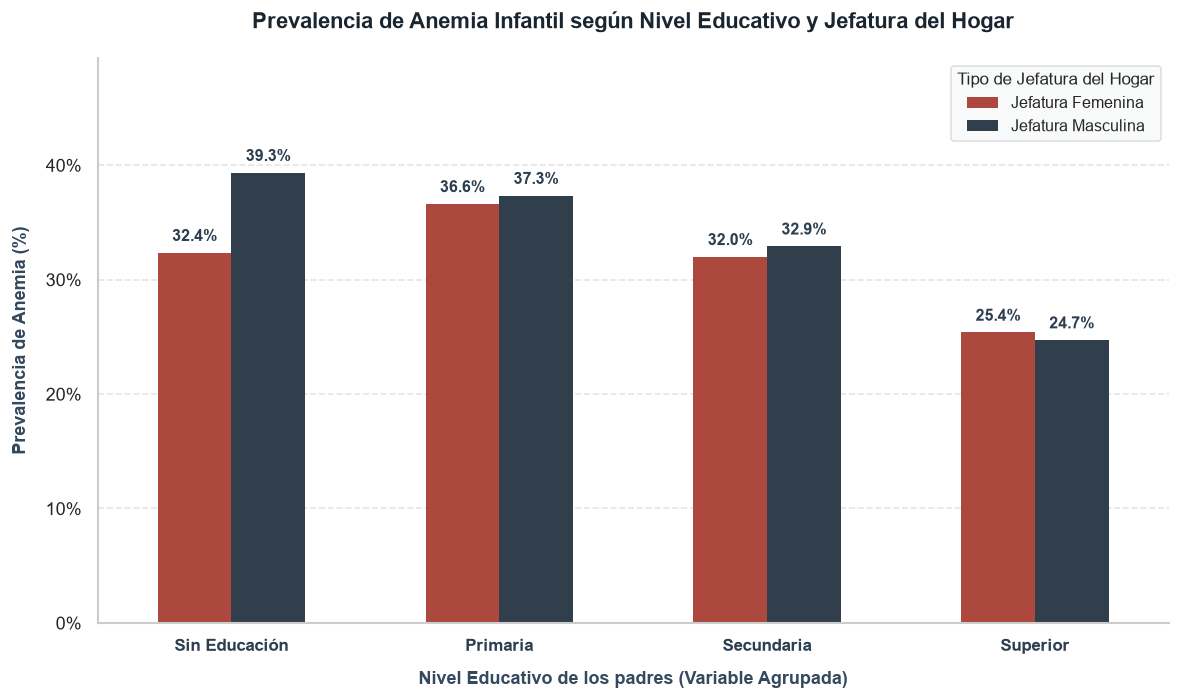

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo editorial
sns.set_theme(style="whitegrid", font="sans-serif")

# =============================================================================
# 1. PREPARACIÓN Y AGREGACIÓN DE DATOS SOCIOEDUCATIVOS
# =============================================================================
# Crear etiqueta descriptiva para la jefatura del hogar
df_merged['desc_jefatura'] = np.where(
    df_merged['es_jefatura_femenina'] == 1, 
    'Jefatura Femenina', 
    'Jefatura Masculina'
)

# Filtrar registros válidos en educación
df_edu = df_merged[df_merged['nivel_educativo_agrupado'] != 'No Especificado'].copy()

# Agregación: Cálculo de prevalencia % y muestra total por grupo
df_grafico = df_edu.groupby(['nivel_educativo_agrupado', 'desc_jefatura']).agg(
    total_niños=('caseid', 'count'),
    casos_anemia=('tiene_anemia', 'sum'),
    pct_anemia=('tiene_anemia', lambda x: x.mean() * 100)
).reset_index()

# Ordenar lógicamente las categorías educativas
orden_educacion = [
    '1. Sin Educación',
    '2. Primaria (Completa e Incompleta)',
    '3. Secundaria (Completa e Incompleta)',
    '4. Superior'
]

df_grafico['nivel_educativo_agrupado'] = pd.Categorical(
    df_grafico['nivel_educativo_agrupado'], 
    categories=orden_educacion, 
    ordered=True
)
df_grafico = df_grafico.sort_values('nivel_educativo_agrupado')

# =============================================================================
# 2. GENERACIÓN DEL GRÁFICO DE BARRAS AGRUPADAS (CLUSTERED BAR CHART)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Paleta de colores ejecutiva (Azul para Masculina, Borgoña para Femenina)
paleta_jefatura = {'Jefatura Masculina': '#2C3E50', 'Jefatura Femenina': '#C0392B'}

ax = sns.barplot(
    data=df_grafico,
    x='nivel_educativo_agrupado',
    y='pct_anemia',
    hue='desc_jefatura',
    palette=paleta_jefatura,
    width=0.55,
    edgecolor='none',
    ax=ax
)

# Títulos y Ejes
ax.set_title('Prevalencia de Anemia Infantil según Nivel Educativo y Jefatura del Hogar', 
             fontsize=13, fontweight='bold', color='#1A252F', pad=18)
ax.set_xlabel('Nivel Educativo de los padres (Variable Agrupada)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)
ax.set_ylabel('Prevalencia de Anemia (%)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)

# Ajuste de etiquetas del Eje X para mejor lectura
etiquetas_x = ['Sin Educación', 'Primaria', 'Secundaria', 'Superior']
ax.set_xticklabels(etiquetas_x, fontsize=10, fontweight='bold', color='#2C3E50')

# Formato del Eje Y
max_y = df_grafico['pct_anemia'].max()
ax.set_ylim(0, max_y + 10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

# Eliminar bordes superior y derecho
sns.despine(top=True, right=True)

# =============================================================================
# 3. ANOTACIONES DE PORCENTAJE (DATA LABELS) Y LEYENDA
# =============================================================================
# Añadir porcentajes sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f'{height:.1f}%',
            xy=(p.get_x() + p.get_width() / 2., height),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2C3E50'
        )

# Leyenda personalizada
ax.legend(
    title="Tipo de Jefatura del Hogar",
    title_fontsize='10',
    fontsize='9.5',
    loc='upper right',
    frameon=True,
    facecolor='#F8F9F9',
    edgecolor='#D5D8DC'
)

# Rejilla tenue horizontal
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analisis del caso:

#### Hallazgos Principales
1. Efecto protector de la educación:
   La prevalencia de anemia disminuye progresivamente conforme aumenta el nivel educativo de los padres.
   En hogares con educación superior, la anemia infantil se reduce a 25.4% (jefatura femenina) y 24.7% (masculina), frente a 39.3% en hogares sin educación.

2. Brecha por tipo de jefatura:
   Las jefaturas masculinas presentan ligeramente mayores tasas de anemia en todos los niveles educativos, aunque la diferencia es menor en niveles altos.
   En hogares sin educación, la brecha es más marcada (39.3% vs. 32.4%), lo que sugiere que la educación materna tiene un efecto más directo en la salud infantil.

3. Transición crítica entre primaria y secundaria:
   El salto de primaria (≈37%) a secundaria (≈32%) muestra una reducción significativa, indicando que la educación básica completa ya genera impacto positivo en prácticas de salud y nutrición.

#### Conclusiones
- La educación parental es un factor determinante en la reducción de la anemia infantil, actuando como un    mecanismo de protección social y sanitaria.
- Las madres con mayor nivel educativo tienden a adoptar mejores prácticas de alimentación, control de crecimiento y suplementación con hierro.
- La brecha por tipo de jefatura refleja diferencias en la gestión del cuidado infantil y el acceso a información sanitaria, especialmente en hogares con menor escolaridad.

#### Acciones Estratégicas Recomendadas
1. Fortalecimiento de la educación materna
    - Integrar módulos de nutrición infantil y salud preventiva en programas de alfabetización y educación básica para madres.
    - Incentivar la continuidad educativa de mujeres jóvenes en zonas rurales mediante becas y programas de retención escolar.

2. Intervención diferenciada por tipo de jefatura
    - Diseñar estrategias de comunicación y acompañamiento específicas para hogares con jefatura masculina, promoviendo la corresponsabilidad en la salud infantil.
    - Implementar talleres de paternidad activa y cuidado nutricional en comunidades con alta prevalencia.

3. Educación sanitaria comunitaria

    - Desarrollar campañas educativas en centros de salud y escuelas sobre prevención de anemia, enfocadas en padres con educación primaria o sin educación formal.
    - Utilizar medios locales y lenguas originarias para garantizar comprensión y apropiación del mensaje.
    - Monitoreo educativo-nutricional



## 4. Gradiente Económico y Distribución del Ingreso

#### Pregunta del Negocio:¿El nivel de riqueza del hogar (v190) actúa como un factor protector ante la anemia infantil en las regiones del Perú?

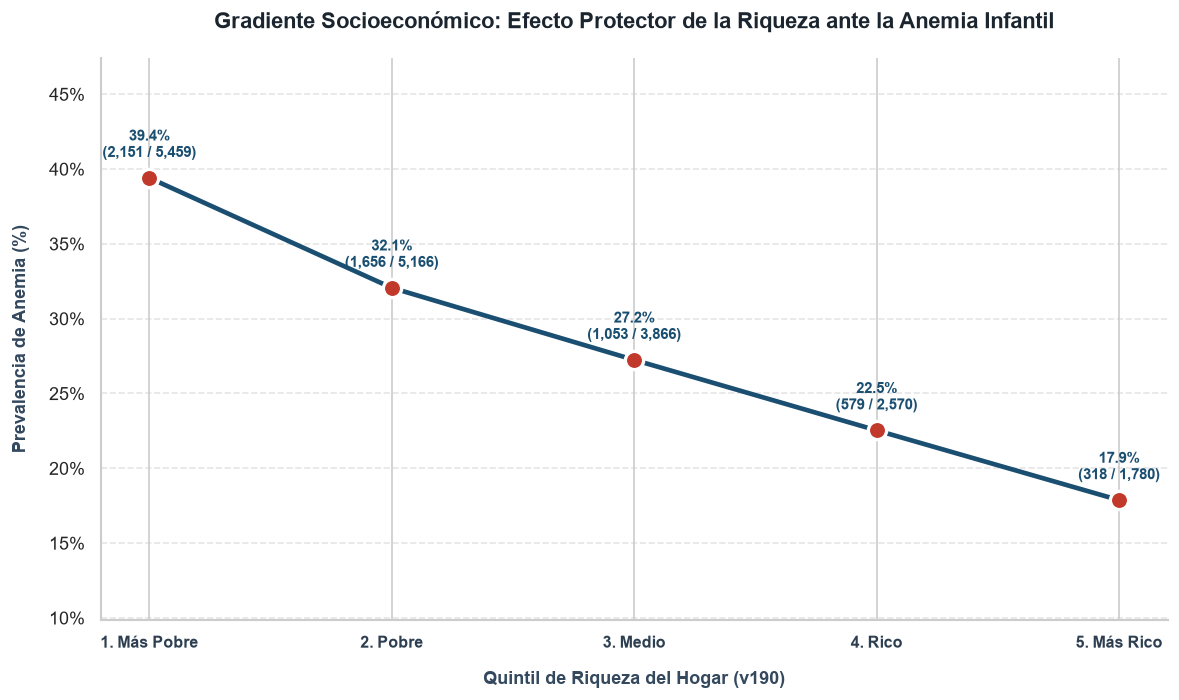

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo editorial
sns.set_theme(style="whitegrid", font="sans-serif")

# =============================================================================
# 1. PREPARACIÓN Y AGREGACIÓN POR QUINTIL DE RIQUEZA (v190)
# =============================================================================
# Diccionario oficial ENDES / DHS para Quintil de Riqueza (v190)
dicc_quintil = {
    1: '1. Más Pobre',
    2: '2. Pobre',
    3: '3. Medio',
    4: '4. Rico',
    5: '5. Más Rico'
}

# Preparación de variables numéricas y etiquetas descriptivas
df_riqueza = df_merged[df_merged['v190'].notnull()].copy()
df_riqueza['v190_num'] = pd.to_numeric(df_riqueza['v190'], errors='coerce')
df_riqueza['desc_quintil'] = df_riqueza['v190_num'].map(dicc_quintil)

# Agregación para cálculo de tasa promedio (%) y muestra por quintil
df_resumen_q = df_riqueza.groupby(['v190_num', 'desc_quintil'], as_index=False).agg(
    total_niños=('caseid', 'count'),
    casos_anemia=('tiene_anemia', 'sum'),
    pct_anemia=('tiene_anemia', lambda x: x.mean() * 100)
).sort_values('v190_num')

# =============================================================================
# 2. GENERACIÓN DEL GRÁFICO DE LÍNEAS CON PUNTOS (POINT PLOT)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Dibujar la línea de tendencia conectando los quintiles
ax.plot(
    df_resumen_q['desc_quintil'], 
    df_resumen_q['pct_anemia'], 
    color='#1B4F72', 
    linewidth=2.8, 
    linestyle='-', 
    zorder=2
)

# Dibujar los puntos sobre cada quintil
ax.scatter(
    df_resumen_q['desc_quintil'], 
    df_resumen_q['pct_anemia'], 
    color='#C0392B', 
    s=120, 
    edgecolor='white', 
    linewidth=2, 
    zorder=3
)

# Títulos y Etiquetas de Ejes
ax.set_title('Gradiente Socioeconómico: Efecto Protector de la Riqueza ante la Anemia Infantil', 
             fontsize=13, fontweight='bold', color='#1A252F', pad=18)
ax.set_xlabel('Quintil de Riqueza del Hogar (v190)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=12)
ax.set_ylabel('Prevalencia de Anemia (%)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=12)

# Formatear Eje Y y ajustar límites con aire superior
max_y = df_resumen_q['pct_anemia'].max()
min_y = df_resumen_q['pct_anemia'].min()
ax.set_ylim(max(0, min_y - 8), max_y + 8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

# Rotación leve de etiquetas en X para lectura fluida
plt.xticks(fontsize=9.5, fontweight='bold', color='#2C3E50')

# Eliminar bordes superior y derecho
sns.despine(top=True, right=True)

# =============================================================================
# 3. ANOTACIONES DE VALORES Y DETALLE DE MUESTRA
# =============================================================================
for i, row in df_resumen_q.iterrows():
    pct = row['pct_anemia']
    casos = int(row['casos_anemia'])
    evaluados = int(row['total_niños'])
    
    # Etiqueta sobre el punto: % destacado y muestra
    ax.annotate(
        f"{pct:.1f}%\n({casos:,} / {evaluados:,})",
        xy=(row['desc_quintil'], pct),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#1B4F72'
    )

# Rejilla tenue horizontal
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analisis del caso:

#### Hallazgos Principales
1. Relación inversa entre riqueza y anemia:

    - La prevalencia de anemia disminuye progresivamente conforme aumenta el quintil de riqueza del hogar.
    - En el quintil más pobre, la tasa alcanza 39.4%, mientras que en el más rico desciende a 17.9%, mostrando una diferencia de 21.5 puntos porcentuales.

2. Evidencia de gradiente socioeconómico sostenido:

    - Cada salto hacia un quintil superior representa una reducción promedio de 4 a 5 puntos porcentuales en la prevalencia.
    - Este patrón lineal indica que el acceso a recursos materiales y servicios básicos tiene un efecto protector acumulativo.

4. Concentración de vulnerabilidad:

    - Los dos primeros quintiles (más pobre y pobre) concentran más del 60% de los casos totales de anemia infantil, lo que los convierte en el núcleo crítico de intervención.

#### Conclusiones
    - El nivel de riqueza del hogar actúa como un factor protector directo frente a la anemia infantil, mediado por mejores condiciones de alimentación, vivienda y acceso a servicios de salud.

    - La desigualdad económica se traduce en desigualdad sanitaria: los niños de hogares pobres enfrentan mayor exposición a dietas deficientes en hierro y menor acceso a suplementación preventiva.

    - Este gradiente confirma que la anemia infantil no solo es un problema nutricional, sino también estructural y social, vinculado a la distribución del ingreso y la calidad de vida.

#### Acciones Estratégicas Recomendadas
1. Focalización territorial y presupuestal

    - Priorizar intervenciones en los quintiles 1 y 2, donde la prevalencia supera el 30%.
    - Asignar recursos diferenciados para suplementación, control CRED y campañas educativas en zonas rurales y urbano-marginales.

2. Programas de transferencia condicionada

    - Fortalecer programas como Juntos y Cuna Más, vinculando los incentivos económicos al cumplimiento de controles de anemia y suplementación infantil.

3. Acceso equitativo a alimentos fortificados

    - Promover subsidios o distribución gratuita de productos ricos en hierro (sangrecita, hígado, menestras fortificadas) en los quintiles más bajos.
    - Impulsar alianzas con productores locales para garantizar sostenibilidad y cobertura.

4. Monitoreo socioeconómico-nutricional

    - Integrar indicadores de riqueza y anemia en los tableros de control del MIDIS y MINSA, permitiendo evaluar el impacto de políticas sociales sobre la salud infantil.

## 5. Perfil Longitudinal: Trayectoria Clinica según Edad en Meses

#### Pregunta del Negocio: ¿En qué mes exacto de vida del menor (0 a 59 meses) se registra el punto más crítico de caída en los niveles de hemoglobina y mayor riesgo de anemia?


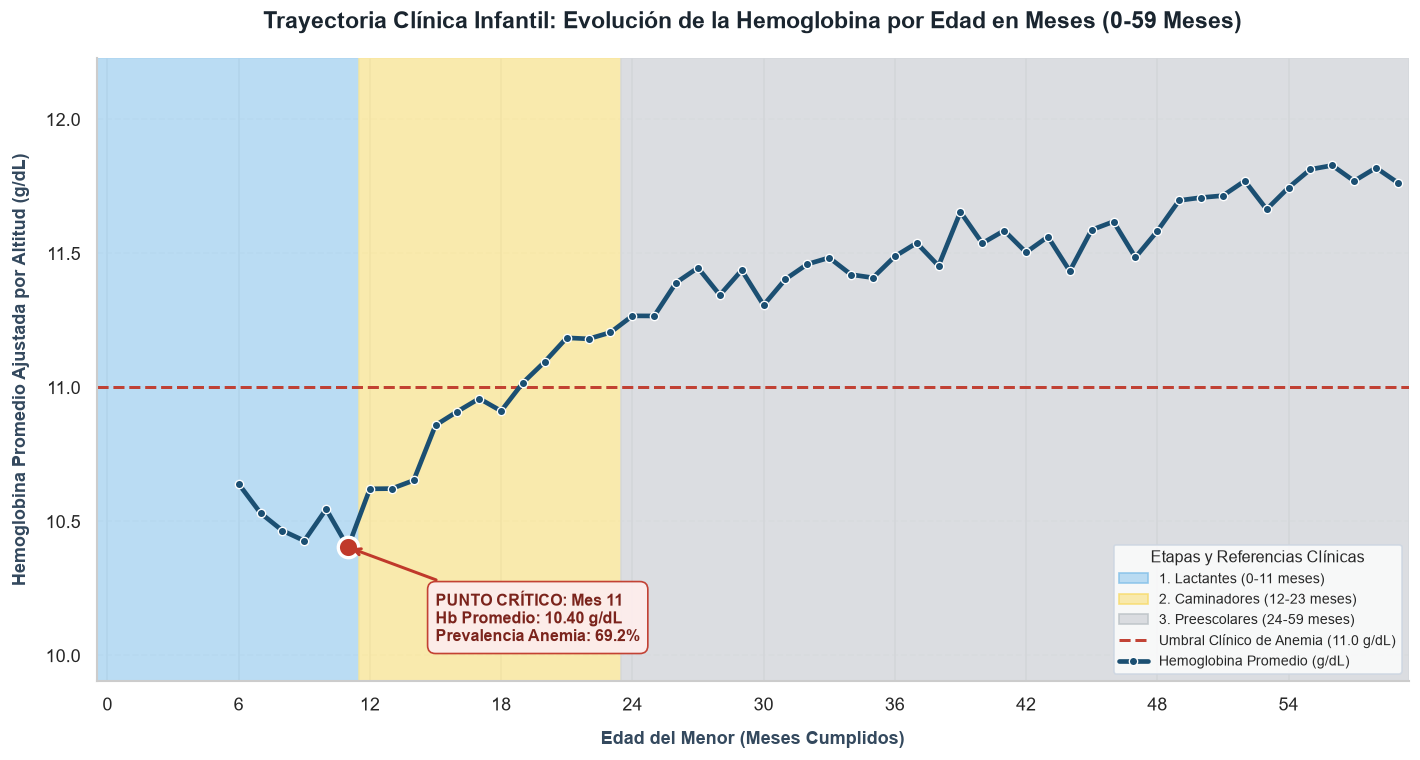

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Configuración de estilo editorial
sns.set_theme(style="whitegrid", font="sans-serif")

# =============================================================================
# 1. PREPARACIÓN Y AGREGACIÓN POR EDAD EN MESES (0 A 59 MESES)
# =============================================================================
df_pediatrico = df_merged[
    (df_merged['edad_meses_num'] >= 0) & 
    (df_merged['edad_meses_num'] <= 59) & 
    (df_merged['hemoglobina_g_dl'].notnull())
].copy()

df_meses = df_pediatrico.groupby('edad_meses_num', as_index=False).agg(
    prom_hb=('hemoglobina_g_dl', 'mean'),
    pct_anemia=('tiene_anemia', lambda x: x.mean() * 100),
    total_niños=('caseid', 'count')
).sort_values('edad_meses_num')

# Ubicar automáticamente el punto crítico
mes_critico_row = df_meses.loc[df_meses['prom_hb'].idxmin()]
mes_min = int(mes_critico_row['edad_meses_num'])
hb_min = mes_critico_row['prom_hb']
anemia_min = mes_critico_row['pct_anemia']

# =============================================================================
# 2. COLORES CON MAYOR INTENSIDAD Y SATURACIÓN
# =============================================================================
# Tonos con mayor presencia visual
COLOR_LACTANTE = '#AED6F1'     # Azul pastel más intenso
COLOR_CAMINADOR = '#F9E79F'    # Amarillo cálido más visible
COLOR_PREESCOLAR = '#D5D8DC'   # Gris medio definido
ALPHA_SOMBRA = 0.85            # Opacidad alta para sombras bien marcadas

fig, ax = plt.subplots(figsize=(12, 6.5), dpi=120)

# A) Sombras de fondo intensas
ax.axvspan(-0.5, 11.5, color=COLOR_LACTANTE, alpha=ALPHA_SOMBRA, zorder=1)
ax.axvspan(11.5, 23.5, color=COLOR_CAMINADOR, alpha=ALPHA_SOMBRA, zorder=1)
ax.axvspan(23.5, 59.5, color=COLOR_PREESCOLAR, alpha=ALPHA_SOMBRA, zorder=1)

# B) Línea del umbral clínico OMS (11.0 g/dL)
linea_oms = ax.axhline(
    y=11.0, color='#C0392B', linestyle='--', linewidth=1.8, alpha=0.95, 
    zorder=2, label='Umbral Clínico de Anemia (11.0 g/dL)'
)

# C) Línea principal de tendencia (Azul Marino con borde blanco para destacar sobre el fondo)
linea_hb = ax.plot(
    df_meses['edad_meses_num'], 
    df_meses['prom_hb'], 
    color='#1B4F72', 
    linewidth=2.8, 
    marker='o', 
    markersize=5, 
    markeredgecolor='white',
    markeredgewidth=0.8,
    zorder=4, 
    label='Hemoglobina Promedio (g/dL)'
)[0]

# D) Resaltado del Punto Crítico (Mes 11)
ax.scatter(
    [mes_min], [hb_min], 
    color='#C0392B', 
    s=150, 
    edgecolor='white', 
    linewidth=2, 
    zorder=5
)

# Anotación destacada
ax.annotate(
    f'PUNTO CRÍTICO: Mes {mes_min}\nHb Promedio: {hb_min:.2f} g/dL\nPrevalencia Anemia: {anemia_min:.1f}%',
    xy=(mes_min, hb_min),
    xytext=(mes_min + 4, hb_min - 0.35),
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.8),
    fontsize=9.5, fontweight='bold', color='#7B241C',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FDEDEC', edgecolor='#C0392B', alpha=0.95),
    zorder=6
)

# =============================================================================
# 3. LEYENDA Y FORMATO FINAL
# =============================================================================
# Títulos y Ejes
ax.set_title('Trayectoria Clínica Infantil: Evolución de la Hemoglobina por Edad en Meses (0-59 Meses)', 
             fontsize=13.5, fontweight='bold', color='#1A252F', pad=18)
ax.set_xlabel('Edad del Menor (Meses Cumplidos)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)
ax.set_ylabel('Hemoglobina Promedio Ajustada por Altitud (g/dL)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)

ax.set_xticks(np.arange(0, 60, 6))
ax.set_xlim(-0.5, 59.5)

min_y = df_meses['prom_hb'].min()
max_y = df_meses['prom_hb'].max()
ax.set_ylim(min_y - 0.5, max_y + 0.4)

# Parches manuales con la misma opacidad intensa para la leyenda
patch_lactante = Patch(facecolor=COLOR_LACTANTE, alpha=ALPHA_SOMBRA, edgecolor='#85C1E9', label='1. Lactantes (0-11 meses)')
patch_caminador = Patch(facecolor=COLOR_CAMINADOR, alpha=ALPHA_SOMBRA, edgecolor='#F7DC6F', label='2. Caminadores (12-23 meses)')
patch_preescolar = Patch(facecolor=COLOR_PREESCOLAR, alpha=ALPHA_SOMBRA, edgecolor='#BDC3C7', label='3. Preescolares (24-59 meses)')

handles_leyenda = [
    patch_lactante, 
    patch_caminador, 
    patch_preescolar, 
    linea_oms, 
    linea_hb
]

ax.legend(
    handles=handles_leyenda,
    loc='lower right', 
    title='Etapas y Referencias Clínicas', 
    title_fontsize='9.5', 
    fontsize='8.5', 
    frameon=True, 
    facecolor='#FFFFFF', 
    edgecolor='#CBD5E1'
)

sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=3)

plt.tight_layout()
plt.show()

## Analisis del Caso:

#### Hallazgos Principales:
1. Punto crítico al mes 11: 
La hemoglobina alcanza su nivel mínimo ($10.40\text{ g/dL}$) a los 11 meses, registrando el pico de prevalencia de anemia en el $69.2% de los niños.
2. Zona de riesgo prolongada: Entre los 6 y 18 meses, la hemoglobina promedio se mantiene persistentemente por debajo del umbral clínico de la OMS (11.0 g/dL).
3. Recuperación progresiva: A partir de los 19-20 meses, la curva se recupera de forma sostenida superando los 11.5 g/dL hacia la etapa preescolar.

#### Conclusiones: 
1. Agotamiento de reservas: La vulnerabilidad extrema entre los 6 y 18 meses responde al agotamiento del hierro materno, al acelerado crecimiento y a fallas en la alimentación complementaria.
2. Secuelas por intervención tardía: La recuperación natural posterior no revierte el impacto cognitivo causado durante el valle crítico del primer año.
3. Inflexión clave: Las acciones estatales que inician a los 12 meses resultan extemporáneas al actuar cuando cerca del 70% de la población ya presenta anemia.

#### Acciones Estratégicas:
 1. RecomendadasSuplementación anticipada (4-6 meses): Iniciar la entrega de hierro y el tamizaje preventivo antes de los 6 meses para proteger las reservas nativas.
 2. Alimentación rica en hierro hemínico: Promover activamente el consumo diario de sangrecita, hígado y bazo desde el inicio de la alimentación complementaria (6 meses).
 3. Control estricto en hitos CRED: Priorizar el monitoreo obligatorio a los 6, 9 y 12 meses como indicador clave de gestión en los centros de salud.

## 5.1 Prevalencia de Anemia (%) según Etapa Pediátrica

### Pregunta: ¿En qué meses o rangos de edad se concentra la mayor caída crítica de hemoglobina?

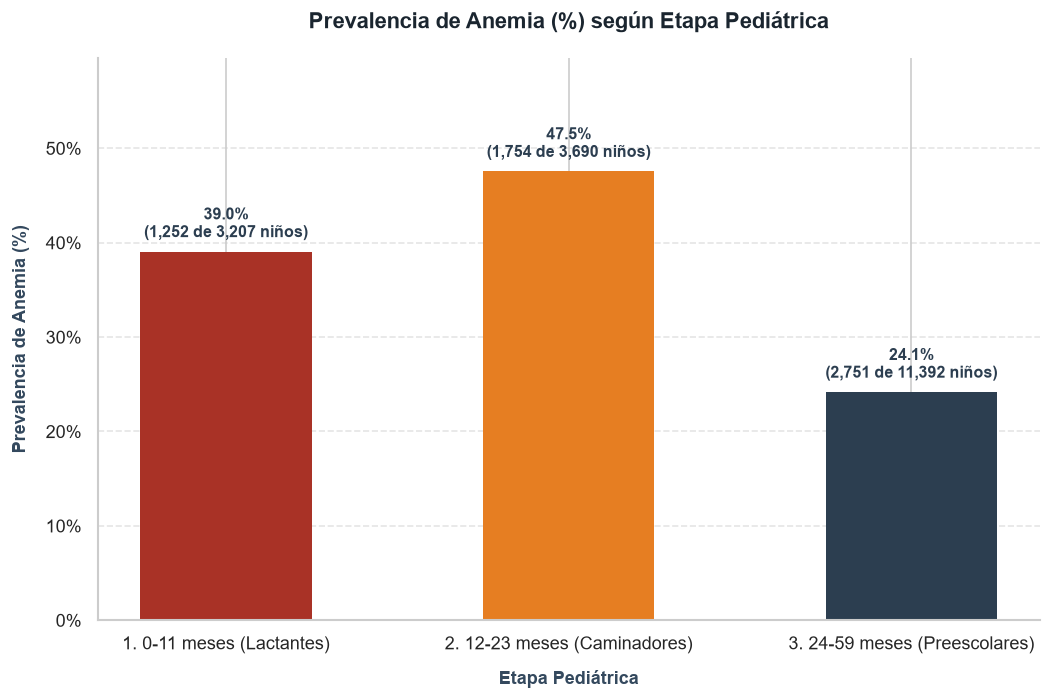

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo editorial
sns.set_theme(style="whitegrid", font="sans-serif")

# =============================================================================
# 1. CÁLCULO DE MÉTRICAS EXACTAS POR ETAPA
# =============================================================================
df_etapas = df_merged.groupby('rango_edad_child', observed=True).agg(
    total_niños=('caseid', 'count'),
    casos_anemia=('tiene_anemia', 'sum'),
    tasa_anemia_pct=('tiene_anemia', lambda x: x.mean() * 100)
).reset_index()

# =============================================================================
# 2. GENERACIÓN DEL GRÁFICO DE BARRAS DE PREVALENCIA REAL
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6), dpi=120)

colores = ['#A93226', '#E67E22', '#2C3E50']  # Rojo Crítico, Naranja Alto, Azul Oscuro

bars = ax.bar(
    df_etapas['rango_edad_child'], 
    df_etapas['tasa_anemia_pct'], 
    color=colores, 
    width=0.5,
    edgecolor='none'
)

# Títulos y Ejes
ax.set_title('Prevalencia de Anemia (%) según Etapa Pediátrica', 
             fontsize=13, fontweight='bold', color='#1A252F', pad=18)
ax.set_xlabel('Etapa Pediátrica', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)
ax.set_ylabel('Prevalencia de Anemia (%)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)

# Formatear Eje Y
max_y = df_etapas['tasa_anemia_pct'].max()
ax.set_ylim(0, max_y + 12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

# Etiquetas exactas sobre cada barra (% y total de niños afectados)
for i, bar in enumerate(bars):
    h = bar.get_height()
    casos = int(df_etapas.loc[i, 'casos_anemia'])
    total = int(df_etapas.loc[i, 'total_niños'])
    
    ax.annotate(
        f'{h:.1f}%\n({casos:,} de {total:,} niños)',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=9.5, fontweight='bold', color='#2C3E50'
    )

sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analisis del caso:

#### ¿Por qué difieren el gráfico de líneas y el gráfico de barras sobre el punto crítico?
- El gráfico de líneas evalúa mes a mes: Muestra el comportamiento individual continuo donde la hemoglobina toca su fondo más bajo exactamente al mes 11 (alcanzando cerca del 69% de prevalencia en ese mes específico).
- El gráfico de barras agrupa periodos completos: La barra de Lactantes (0-11 meses) promedia a todos los niños de 0 a 11 meses (incluyendo a los de 0 a 5 meses que casi no tienen anemia), lo que "suaviza" la barra hasta un 39.0%. 
- En cambio, la barra de Caminadores (12-23 meses) registra 47.5% porque arrastra de golpe todo el impacto y las secuelas del punto crítico ocurrido a finales del primer año.

#### Hallazgos Principales:
1. Inflexión del mes 11: La caída más severa de hemoglobina ocurre puntualmente al mes 11 de vida, alcanzando un mínimo promedio de 10.40 g/dL y un pico individual del 69.2% de prevalencia.
2. Pico acumulado en caminadores: La etapa de 12 a 23 meses (Caminadores) registra la tasa promedio agrupada más alta (47.5%), al concentrar el arrastre de la caída ocurrida en el mes 11.
3. Persistencia en preescolares: Aunque la hemoglobina se recupera al crecer, 1 de cada 4 niños (24.1%) en la etapa de 24 a 59 meses aún padece anemia.

#### Conclusiones:
1. Efecto de arrastre: La anemia toca su punto más bajo al mes 11, pero se manifiesta con mayor fuerza en los promedios del segundo año de vida (12-23 meses) si no se trata a tiempo.
2. Promedios engañosos: Agrupar datos por bloques amplios de edad oculta el momento exacto del colapso de hemoglobina que el gráfico mensual sí revela con precisión.
3. Vulnerabilidad sostenida: La recuperación progresiva a partir de los 24 meses disminuye el porcentaje de afectados, pero no elimina la condición en la etapa preescolar.

#### Acciones Estratégicas Recomendadas:
1. Intervención anticipada (4–6 meses): Iniciar la suplementación con hierro antes de los 6 meses para evitar el colapso de reservas que ocurre en el mes 11.
2. Tamizaje obligatorio en CRED: Priorizar el control de hemoglobina obligatoria a los 6 y 9 meses para detectar la caída antes de que pase a la etapa de caminadores.
3. Continuidad en el segundo año: Mantener la consejería nutricional y suplementación hasta los 23 meses para revertir el $47.5\%$ de anemia acumulada en esa etapa.

## 5.2 Distribución y Densidad de Hemoglobina Ajustada por Etapa Pediátrica

#### Pregunta: ¿Cómo se distribuyen, dispersan y concentran los niveles de hemoglobina ajustada en la población infantil a lo largo de las distintas etapas pediátricas (0 a 59 meses), y qué proporción de la población se encuentra por debajo del umbral clínico de anemia ($11.0\text{ g/dL}$) en cada etapa?

C:\Users\ANGELICA\AppData\Local\Temp\ipykernel_24024\301158325.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ANGELICA\AppData\Local\Temp\ipykernel_24024\301158325.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


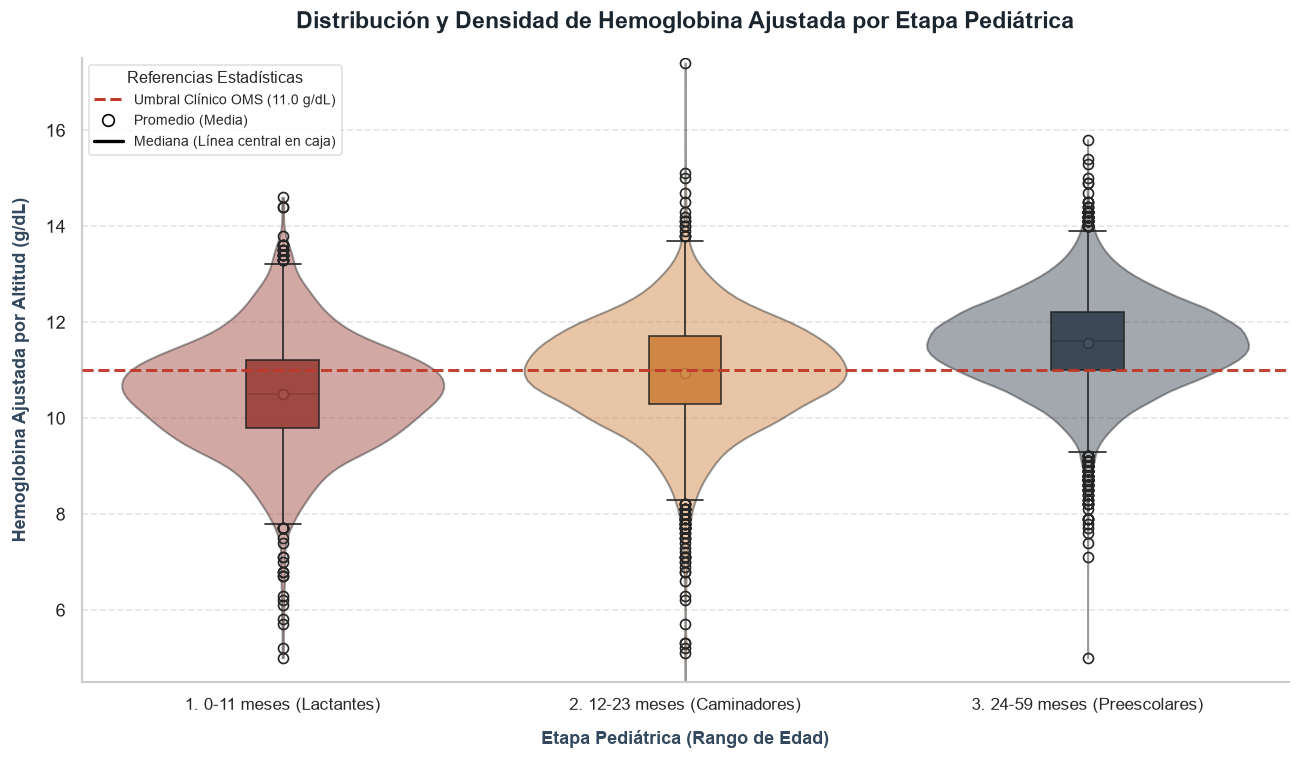

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo editorial
sns.set_theme(style="whitegrid", font="sans-serif")

# =============================================================================
# 1. PREPARACIÓN Y FILTRADO DE DATOS (endes_2025_nutricion_m1638_enriquecido)
# =============================================================================
# Filtrar registros válidos en hemoglobina y etapas pediátricas
df_violin = df_merged[
    (df_merged['hemoglobina_g_dl'].notnull()) & 
    (df_merged['rango_edad_child'].notnull())
].copy()

# Paleta de colores ejecutiva por etapa pediátrica
paleta_etapas = {
    '1. 0-11 meses (Lactantes)': '#A93226',     # Rojo Crítico
    '2. 12-23 meses (Caminadores)': '#E67E22', # Naranja Alto
    '3. 24-59 meses (Preescolares)': '#2C3E50'  # Azul Oscuro
}

# =============================================================================
# 2. GENERACIÓN DEL GRÁFICO COMBINADO VIOLIN + BOX PLOT
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=120)

# A) Gráfico de Violín (Densidad de la Distribución)
sns.violinplot(
    data=df_violin,
    x='rango_edad_child',
    y='hemoglobina_g_dl',
    palette=paleta_etapas,
    inner=None,          # Se omite el interior por defecto para dibujar la caja personalizada
    alpha=0.45,          # Opacidad para no recargar visualmente
    cut=0,               # Cortar violín al rango de datos reales
    linewidth=1.2,
    ax=ax
)

# B) Box Plot superpuesto (Cuartiles, Mediana y Rango Intercuartílico)
sns.boxplot(
    data=df_violin,
    x='rango_edad_child',
    y='hemoglobina_g_dl',
    width=0.18,          # Ancho delgado para calzar dentro del violín
    palette=paleta_etapas,
    showmeans=True,      # Mostrar el promedio como punto blanco
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "6"},
    boxprops={"zorder": 3, "alpha": 0.9},
    ax=ax
)

# C) Línea de referencia del Umbral Clínico OMS (11.0 g/dL)
ax.axhline(
    y=11.0, 
    color='#C0392B', 
    linestyle='--', 
    linewidth=1.8, 
    alpha=0.95, 
    zorder=4, 
    label='Umbral Clínico de Anemia (11.0 g/dL)'
)

# =============================================================================
# 3. DETALLES ESTÉTICOS, ANOTACIONES Y FORMATO
# =============================================================================
# Títulos y Ejes
ax.set_title('Distribución y Densidad de Hemoglobina Ajustada por Etapa Pediátrica', 
             fontsize=13.5, fontweight='bold', color='#1A252F', pad=18)
ax.set_xlabel('Etapa Pediátrica (Rango de Edad)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)
ax.set_ylabel('Hemoglobina Ajustada por Altitud (g/dL)', fontsize=10.5, fontweight='bold', color='#34495E', labelpad=10)

# Ajuste de límites y rejilla
ax.set_ylim(4.5, 17.5)
ax.tick_params(axis='x', labelsize=10)

# Leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#C0392B', lw=1.8, linestyle='--', label='Umbral Clínico OMS (11.0 g/dL)'),
    Line2D([0], [0], marker='o', color='w', label='Promedio (Media)', markerfacecolor='white', markeredgecolor='black', markersize=7),
    Line2D([0], [0], color='black', lw=2, label='Mediana (Línea central en caja)')
]

ax.legend(
    handles=legend_elements, 
    loc='upper left', 
    title='Referencias Estadísticas', 
    title_fontsize='9.5', 
    fontsize='8.5', 
    frameon=True, 
    facecolor='#FFFFFF', 
    edgecolor='#D5D8DC'
)

# Limpieza de bordes
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

## Analisis del Gráfico:

1. ¿Cómo se lee cada parte del gráfico?
    
    a. La Sombra del Violín (Ancho): Representa dónde se concentra la mayor cantidad de niños. Cuanto más "ancha" es la figura a una determinada altura de hemoglobina, más niños tienen ese valor exacto.
    
    b. La Caja Central (Box Plot): Contiene al $50\%$ central de los niños (el rango intercuartílico). La línea horizontal dentro de la caja es la mediana (el punto medio exacto de la población) y el círculo blanco representa el promedio.
    
    c. Los Círculos Sueltos (Extremos): Son valores atípicos (outliers), es decir, niños con niveles de hemoglobina inusualmente bajos ($<8\text{ g/dL}$) o muy altos.
    
    d. La Línea Roja Punteada (11.0 g/dL): Es el umbral clínico de la OMS. Todo lo que quede por debajo de esta línea es área de anemia.

2. Interpretación Clínica por Etapas Pediátricas
    
    a. Lactantes (0-11 meses) — Violín Rojo:
        
        - Ubicación: Más de la mitad del violín y casi toda la caja están por debajo de la línea roja 11.0 g/dL.
        
        - Significado: Muestra una alta concentración de niños con niveles bajos de hemoglobina. La parte más ancha del violín se ubica alrededor de los 10.5 g/dL, lo que confirma la gran vulnerabilidad en el primer año.
    
    b. Caminadores (12-23 meses) — Violín Naranja:
        
        - Ubicación: La caja se desplaza ligeramente hacia arriba, pero la mediana (línea interna) está justo sobre el umbral de 11.0 g/dL.
        
        - Significado: Muestra una población en transición. Aunque el promedio sube, una gran "panza" del violín sigue estando en la zona de anemia, reflejando el arrastre de la caída ocurrida en el primer año. 
    
    c. Preescolares (24-59 meses) — Violín Gris:
        
        - Ubicación: La caja y la parte más ancha del violín se desplazan claramente por encima de la línea roja (alrededor de 11.5 - 12.0 g/dL).
        
        - Significado: La mayoría de los niños alcanza niveles saludables de hemoglobina. Sin embargo, la "cola" inferior del violín que se extiende hacia abajo muestra que aún existe un grupo minoritario de preescolares con anemia.

3. Resumen Ejecutivo del Gráfico Tendencia: 
    - La figura muestra un desplazamiento progresivo hacia arriba a medida que los niños crecen (de lactantes a preescolares).
    - Conclusión clave: El riesgo no se distribuye por igual: en los Lactantes, la mayor densidad poblacional vive en "zona de anemia" (debajo de la línea roja), mientras que en los Preescolares la densidad se traslada a "zona saludable".